📂 Upload heart.csv


Saving heart.csv to heart (2).csv

✅ Dataset Loaded Successfully!

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbp

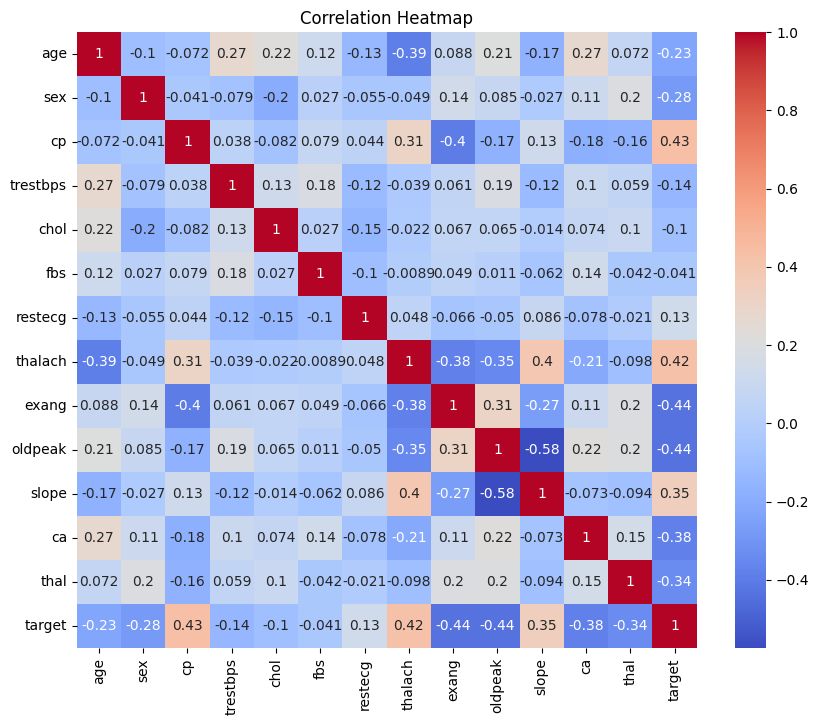


✅ Preprocessing Done!

🔹 Training Logistic Regression...
✔ Accuracy: 80.98%
              precision    recall  f1-score   support

           0       0.89      0.70      0.78       100
           1       0.76      0.91      0.83       105

    accuracy                           0.81       205
   macro avg       0.82      0.81      0.81       205
weighted avg       0.82      0.81      0.81       205



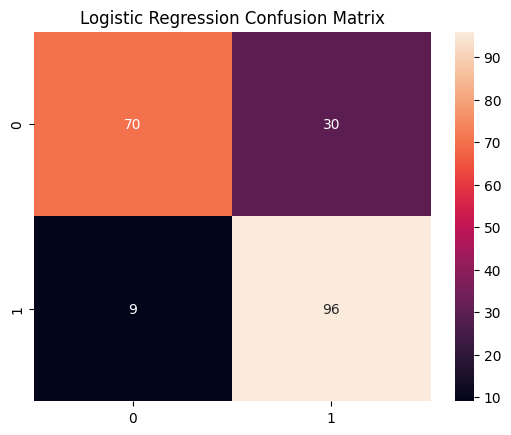


🔹 Training Naive Bayes...
✔ Accuracy: 82.93%
              precision    recall  f1-score   support

           0       0.86      0.78      0.82       100
           1       0.81      0.88      0.84       105

    accuracy                           0.83       205
   macro avg       0.83      0.83      0.83       205
weighted avg       0.83      0.83      0.83       205



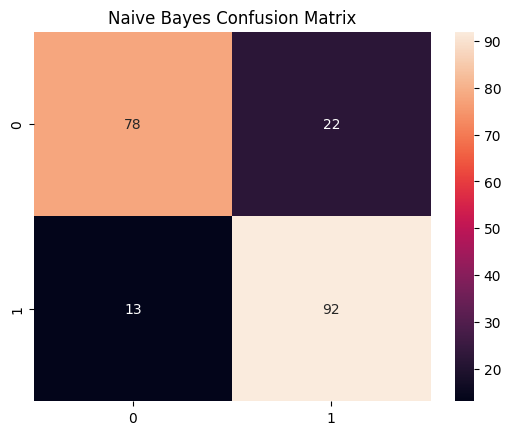


🔹 Training SVM...
✔ Accuracy: 81.46%
              precision    recall  f1-score   support

           0       0.90      0.70      0.79       100
           1       0.76      0.92      0.84       105

    accuracy                           0.81       205
   macro avg       0.83      0.81      0.81       205
weighted avg       0.83      0.81      0.81       205



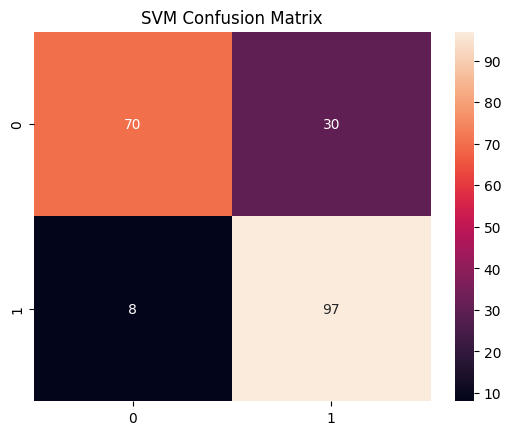


🔹 Training Bagging...
✔ Accuracy: 80.98%
              precision    recall  f1-score   support

           0       0.87      0.72      0.79       100
           1       0.77      0.90      0.83       105

    accuracy                           0.81       205
   macro avg       0.82      0.81      0.81       205
weighted avg       0.82      0.81      0.81       205



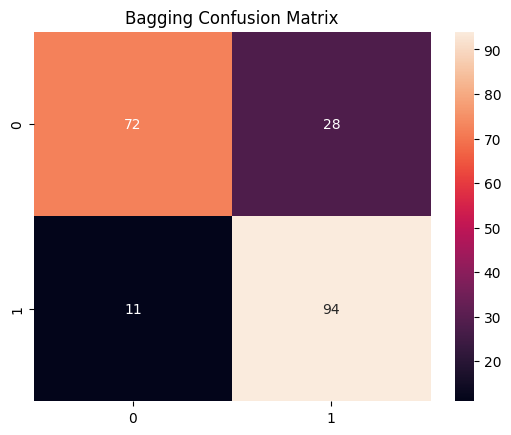

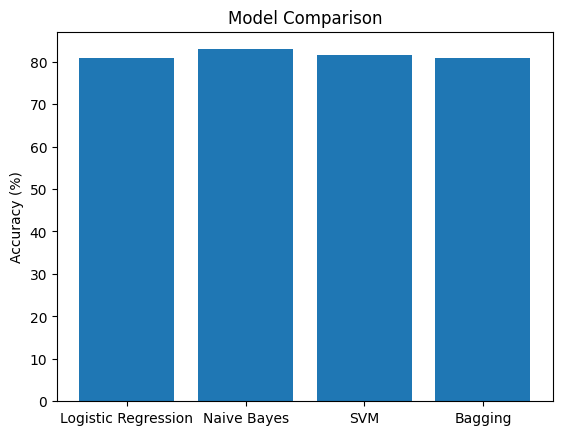


🏆 Best Model: Naive Bayes
Accuracy: 82.93%
Cross Validation: [0.87317073 0.82926829 0.84390244 0.7902439  0.77073171]
Mean Accuracy: 82.14634146341464


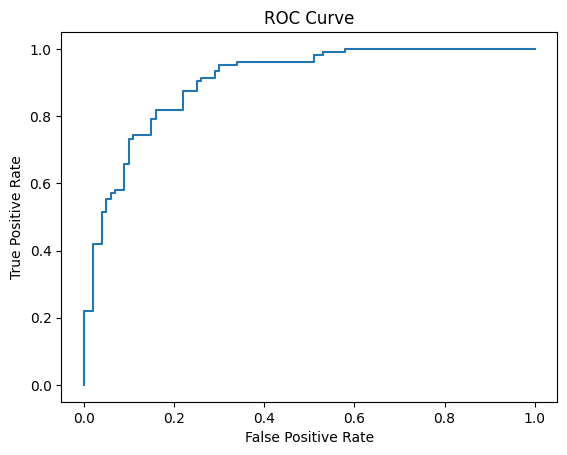


💾 Model Saved Successfully!

🚀 Launching App...
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://d059c672b18fd5c306.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [2]:
# ================================================================
# ❤ HEART DISEASE PREDICTION — FINAL ADVANCED PROJECT
# ================================================================

!pip install -q gradio pandas numpy scikit-learn seaborn matplotlib

# ================= IMPORT LIBRARIES =================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import io

from google.colab import files
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc

import gradio as gr

# ================= LOAD DATA =================
print("📂 Upload heart.csv")
uploaded = files.upload()

filename = next(iter(uploaded.keys()))

try:
    df = pd.read_csv(io.BytesIO(uploaded[filename]))
    print("\n✅ Dataset Loaded Successfully!\n")
except:
    print("❌ Error loading file")

print(df.head())
print(df.info())
print("\nMissing Values:\n", df.isnull().sum())

# ================= HEATMAP =================
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# ================= PREPROCESSING =================
df = df.dropna()

X = df.drop("target", axis=1)
y = df["target"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print("\n✅ Preprocessing Done!")

# ================= MODELS =================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": GaussianNB(),
    "SVM": SVC(kernel="linear", probability=True),
    "Bagging": BaggingClassifier(
        estimator=LogisticRegression(max_iter=1000),
        n_estimators=10,
        random_state=42
    )
}

# ================= TRAINING =================
results = {}

for name, model in models.items():
    print(f"\n🔹 Training {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

    print(f"✔ Accuracy: {acc*100:.2f}%")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='g')
    plt.title(f"{name} Confusion Matrix")
    plt.show()

# ================= BAR GRAPH =================
plt.bar(results.keys(), [v*100 for v in results.values()])
plt.title("Model Comparison")
plt.ylabel("Accuracy (%)")
plt.show()

# ================= BEST MODEL =================
best_model_name = max(results, key=results.get)
best_model = models[best_model_name]

print(f"\n🏆 Best Model: {best_model_name}")
print(f"Accuracy: {results[best_model_name]*100:.2f}%")

# ================= CROSS VALIDATION =================
cv_scores = cross_val_score(best_model, X_scaled, y, cv=5)
print("Cross Validation:", cv_scores)
print("Mean Accuracy:", cv_scores.mean()*100)

# ================= FEATURE IMPORTANCE =================
if best_model_name == "Logistic Regression":
    importance = best_model.coef_[0]
    plt.bar(X.columns, importance)
    plt.xticks(rotation=45)
    plt.title("Feature Importance")
    plt.show()

# ================= ROC CURVE =================
y_prob = best_model.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

# ================= SAVE MODEL =================
pickle.dump(best_model, open("model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))

print("\n💾 Model Saved Successfully!")

# ================= PREDICTION FUNCTION =================
def predict_heart(age, sex, cp, trestbps, chol, fbs, restecg,
                  thalach, exang, oldpeak, slope, ca, thal):

    data = np.array([[age, sex, cp, trestbps, chol, fbs, restecg,
                      thalach, exang, oldpeak, slope, ca, thal]])

    data_scaled = scaler.transform(data)
    pred = best_model.predict(data_scaled)[0]
    prob = best_model.predict_proba(data_scaled)[0][1]*100

    if pred == 1:
        return f"⚠ High Risk ({prob:.2f}%)"
    else:
        return f"✅ Low Risk ({prob:.2f}%)"

# ================= GRADIO UI =================
inputs = [
    gr.Number(label="Age", minimum=20, maximum=100),
    gr.Radio([0,1], label="Sex (0=Female,1=Male)"),
    gr.Slider(0,3,label="Chest Pain"),
    gr.Number(label="BP"),
    gr.Number(label="Cholesterol"),
    gr.Radio([0,1], label="FBS"),
    gr.Slider(0,2,label="ECG"),
    gr.Number(label="Heart Rate"),
    gr.Radio([0,1], label="Angina"),
    gr.Number(label="Oldpeak"),
    gr.Slider(0,2,label="Slope"),
    gr.Slider(0,4,label="CA"),
    gr.Slider(1,3,label="Thal")
]

app = gr.Interface(
    fn=predict_heart,
    inputs=inputs,
    outputs="text",
    title="❤ Heart Disease Predictor",
    description="Advanced ML Model with UI"
)

print("\n🚀 Launching App...")
app.launch(share=True)